In [22]:
import pandas as pd

# Define the data for the table
data = {
    'Task': [
        'Data Preprocessing', 'Image Augmentation', 'Train and test data handled correctly',
        'Gaussian Blur, Histogram Equalization and Intensity thresholds', 'Model Trained', 
        'AUC and Confusion Matrix Computed', 'Overfitting/Underfitting checked and handled',
        'Empirical Tuning', '1st Round of Tuning', '2nd Round of Tuning'
    ],
    'Sub-task': [
        'Scaling and Resizing', 'Done/Not Done', 'Done/Not Done', 'Done/Not Done', 'Training Time?',
        'Done/Not Done', 'Done/Not Done', 'Interpretability Implemented', 'Issue Faced/Fixed', 'Issue Faced/Fixed'
    ],
    'Comments': [
        'Done', 'Done', 'Done', 'Done', '1020.20 seconds',
        'Done, AUC Score: 0.8821', 'Overfitting', 'LIME Partially Done', 'Partially Done, Best Validation Accuracy: 0.5383', 'Partially Done, Best Validation accuracy: 0.5383'
    ]
}

# Create a DataFrame
Task = pd.DataFrame(data)

# Display the table
Task

,Task,Sub-task,Comments
0,Data Preprocessing,Scaling and Resizing,Done
1,Image Augmentation,Done/Not Done,Done
2,Train and test data handled correctly,Done/Not Done,Done
3,"Gaussian Blur, Histogram Equalization and Inte...",Done/Not Done,Done
4,Model Trained,Training Time?,1020.20 seconds
5,AUC and Confusion Matrix Computed,Done/Not Done,"Done, AUC Score: 0.8821"
6,Overfitting/Underfitting checked and handled,Done/Not Done,Overfitting
7,Empirical Tuning,Interpretability Implemented,LIME Partially Done
8,1st Round of Tuning,Issue Faced/Fixed,"Partially Done, Best Validation Accuracy: 0.5383"
9,2nd Round of Tuning,Issue Faced/Fixed,"Partially Done, Best Validation accuracy: 0.5383"


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import json

In [3]:
# Path to photos.json
json_path = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos.json"

# Load the JSON file
with open(json_path, "r") as f:
    photos_data = [json.loads(line) for line in f]

# Create a dictionary to map photo_id to label
photo_id_to_label = {item["photo_id"]: item["label"] for item in photos_data}

# Data Preprocessing

In [4]:
# Path to the photos folder
dataset_path = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos"

# Function to load and preprocess images
def load_and_preprocess_image(img_path, img_size=(64, 64)):
    try:
        # Read the image file
        img = tf.io.read_file(img_path)
        # Decode the image to a tensor
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        # Resize the image
        img = tf.image.resize(img, img_size)
        # Normalize pixel values to [0, 1]
        img = img / 255.0
        return img
    except:
        # Skip corrupted or unsupported files
        return None

# Load a subset of images (e.g., 10,000 images)
image_paths = [
    os.path.join(dataset_path, filename) 
    for filename in os.listdir(dataset_path) 
    if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))
][:10000]  # Limit to 10,000 images

# Load images and labels
images = []
labels = []
for img_path in image_paths:
    photo_id = os.path.splitext(os.path.basename(img_path))[0]  # Extract photo_id from filename
    if photo_id in photo_id_to_label:  # Check if the photo_id exists in the JSON data
        img = load_and_preprocess_image(img_path)
        if img is not None:  # Only add valid images
            images.append(img)
            labels.append(photo_id_to_label[photo_id])

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

In [5]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2

# Apply Gaussian Blur, Histogram Equalization, and Intensity Thresholding
def preprocess_image_advanced(img):
    # Convert to numpy array (from tensor)
    img = np.array(img * 255, dtype=np.uint8)  # Convert back to 0-255 range

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply Histogram Equalization
    equalized = cv2.equalizeHist(blurred)

    # Apply Intensity Thresholding
    _, thresholded = cv2.threshold(equalized, 127, 255, cv2.THRESH_BINARY)

    # Convert back to 3 channels for CNN input
    processed_img = cv2.cvtColor(thresholded, cv2.COLOR_GRAY2RGB) / 255.0  # Normalize to [0,1]

    return processed_img

# Apply preprocessing to all images
images_processed = np.array([preprocess_image_advanced(img) for img in images])

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(images_processed, labels, test_size=0.2, random_state=42, stratify=labels)

# Apply Image Augmentation only to training data
train_datagen = ImageDataGenerator(
    rotation_range=20, 
    width_shift_range=0.2, 
    height_shift_range=0.2, 
    horizontal_flip=True, 
    zoom_range=0.2
)

# Generate augmented training data
train_generator = train_datagen.flow(X_train, y_train, batch_size=32, shuffle=True)

# Convert test data into batches (without augmentation)
test_generator = ImageDataGenerator().flow(X_test, y_test, batch_size=32, shuffle=False)


# Load Pre-trained VGG16 & Modify Layers

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import time

# Load VGG16 model without the top layer & freeze initial layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Unfreeze some layers for fine-tuning (last 4 layers)
for layer in base_model.layers[:-4]:  
    layer.trainable = False  # Freeze all layers except the last 4

# Build custom classifier on top
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Prevent overfitting
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(len(np.unique(labels)), activation='softmax')(x)  # Corrected # Multi-class classification

# Create final model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model Summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 15,272,773 (58.26 MB)

 Trainable params: 7,637,509 (29.13 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode labels as integers
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)  # Convert string labels to numerical labels

# Train the Model & Track Training Time

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)


In [9]:
import time

# Start timing the training process
start_time = time.time()

# Fit the model on the training data
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Calculate total training time
train_time = time.time() - start_time
print(f"Total Training Time: {train_time:.2f} seconds")



Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 253s 966ms/step - accuracy: 0.5714 - loss: 1.1288 - val_accuracy: 0.7264 - val_loss: 0.7525
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 240s 960ms/step - accuracy: 0.7226 - loss: 0.7857 - val_accuracy: 0.7504 - val_loss: 0.6956
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 238s 951ms/step - accuracy: 0.7565 - loss: 0.6842 - val_accuracy: 0.7689 - val_loss: 0.6514
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 179s 715ms/step - accuracy: 0.7864 - loss: 0.6082 - val_accuracy: 0.7514 - val_loss: 0.6674
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 431ms/step - accuracy: 0.8199 - loss: 0.5059 - val_accuracy: 0.7659 - val_loss: 0.6567
Total Training Time: 1020.20 seconds


# Evaluate Model: AUC & Confusion Matrix

63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step
AUC Score: 0.8821


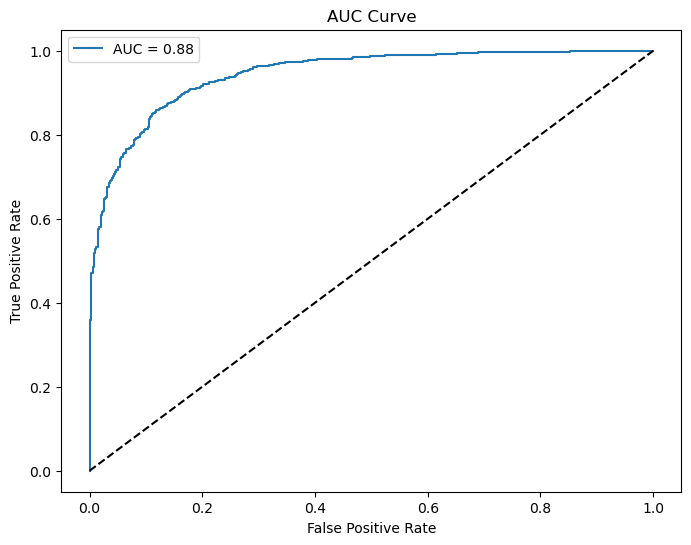

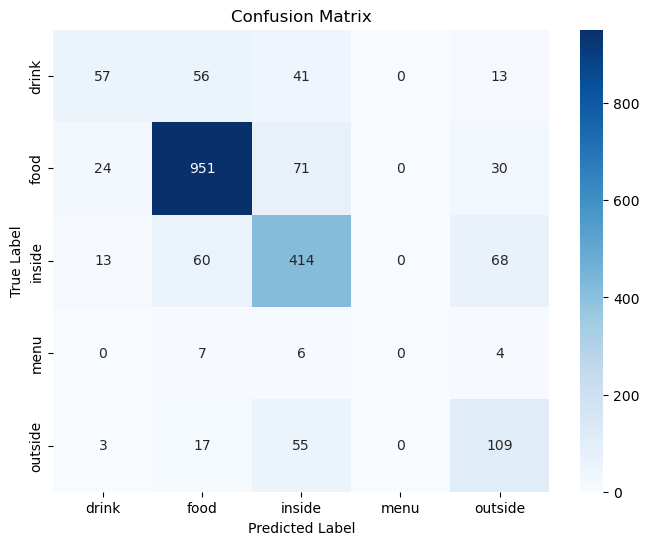

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
y_pred_probs = model.predict(X_test)  # Get probability scores
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels

# Compute AUC Score
auc_score = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f"AUC Score: {auc_score:.4f}")

# Plot AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs[:, 1], pos_label=1)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC Curve")
plt.legend()
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(labels), yticklabels=np.unique(labels))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step


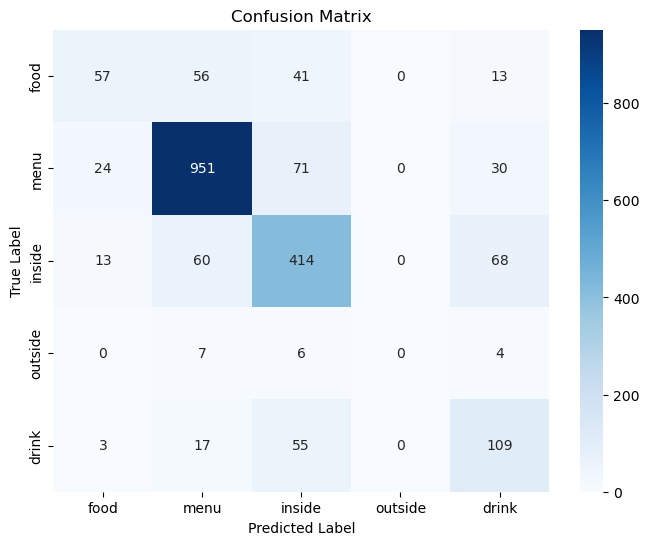

AUC Score: 0.8821


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=set(labels), yticklabels=set(labels))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Compute AUC score
auc_score = roc_auc_score(y_test, y_pred, multi_class="ovr")
print(f"AUC Score: {auc_score:.4f}")


In [12]:
from sklearn.preprocessing import label_binarize

# Convert y_test (numerical labels) into a one-hot encoded format
y_test_binarized = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))


In [13]:
y_pred_probs = model.predict(X_test)  # Get the predicted probabilities for the test set

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 346ms/step


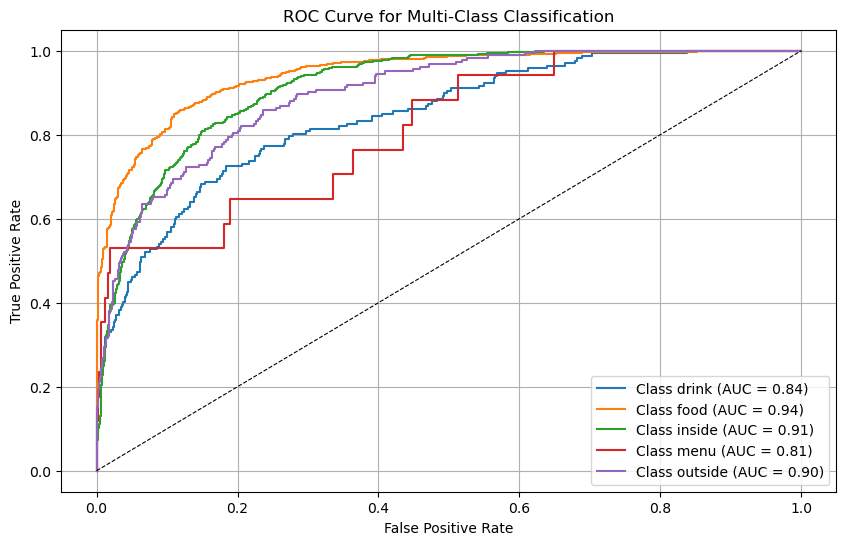

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

for i in range(len(label_encoder.classes_)):  # Loop over each class
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Overfitting/Underfitting handling

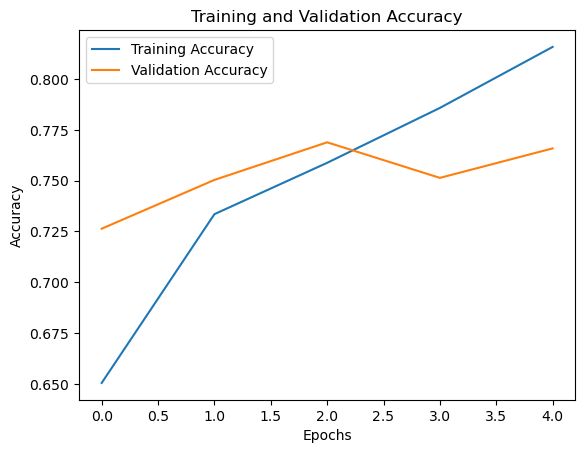

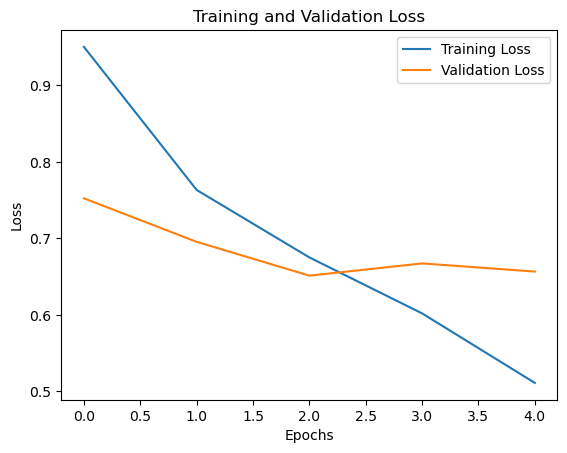

In [15]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [16]:
# Training and validation accuracy values from history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Training and validation loss values from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Check for overfitting or underfitting
def check_overfitting_or_underfitting(train_acc, val_acc, train_loss, val_loss):
    if train_acc[-1] > val_acc[-1] and train_loss[-1] < val_loss[-1]:
        print("Overfitting Detected: Training accuracy is higher than validation accuracy, and training loss is lower than validation loss.")
    elif train_acc[-1] < val_acc[-1] and train_loss[-1] > val_loss[-1]:
        print("Underfitting Detected: Both training and validation performance is poor.")
    elif train_acc[-1] == val_acc[-1] and train_loss[-1] == val_loss[-1]:
        print("Model is well-balanced: Training and validation performance are similar.")
    else:
        print("Model seems to be performing well, but further investigation may be required.")
        
# Call the function to check for overfitting or underfitting
check_overfitting_or_underfitting(train_acc, val_acc, train_loss, val_loss)


Overfitting Detected: Training accuracy is higher than validation accuracy, and training loss is lower than validation loss.


# Model Interpretability

In [17]:
pip install lime


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import lime
import lime.lime_tabular
import numpy as np


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

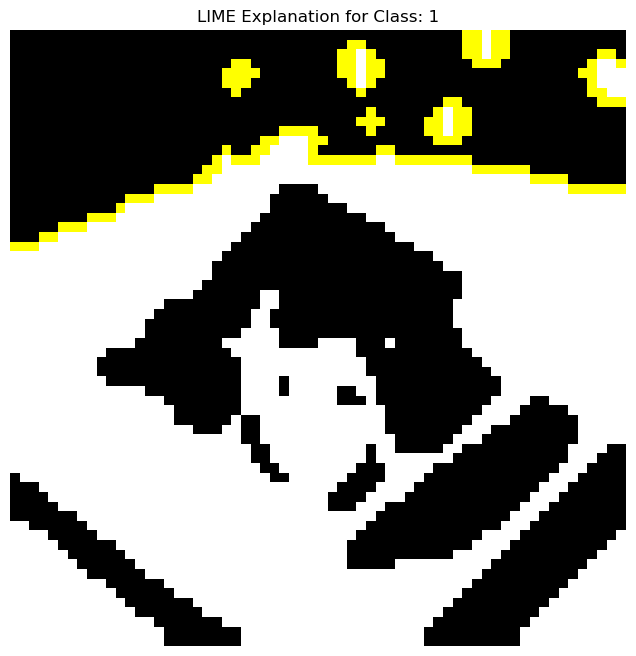

In [19]:
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt

# Initialize LIME Image Explainer
explainer = LimeImageExplainer()

# Choose an image index from X_test
image_idx = 10  # Example: Explain the 10th image
test_sample = X_test[image_idx]  # Extract the image (without reshaping)

# Define the prediction function for LIME
def predict_fn(images):
    images = np.array(images)  # Ensure input is a NumPy array
    return model.predict(images)  # Use your fine-tuned VGG model for prediction

# Get LIME explanation for the test sample
explanation = explainer.explain_instance(
    test_sample,  # The image to explain
    predict_fn,  # Prediction function
    top_labels=5,  # Number of top classes to show explanations for
    hide_color=0,  # Hide background color
    num_samples=1000  # Number of perturbed samples for LIME
)

# Visualizing Explanation for the Top Predicted Class
top_class = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(top_class, positive_only=True, num_features=5, hide_rest=True)

# Display the image with LIME explanation
plt.figure(figsize=(8, 8))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"LIME Explanation for Class: {top_class}")
plt.axis("off")
plt.show()



# Empirical Tuning

In [20]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ensure labels are float32 to avoid dtype errors
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

# Define the ImageDataGenerator with augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Generate augmented training data
train_generator = train_datagen.flow(X_train, y_train, batch_size=32, shuffle=True)

# Convert test data into batches (without augmentation)
test_generator = ImageDataGenerator().flow(X_test, y_test, batch_size=32, shuffle=False)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Function to create the model
def create_model(learning_rate=0.001, dropout_rate=0.5):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Round 1 - Initial Hyperparameter Tuning
round1_model = create_model(learning_rate=0.001, dropout_rate=0.5)
early_stop = EarlyStopping(monitor='val_loss', patience=5)
round1_history = round1_model.fit(train_generator, 
                                  validation_data=test_generator, 
                                  epochs=6, 
                                  callbacks=[early_stop])

# Analyze Round 1 results
round1_val_acc = max(round1_history.history['val_accuracy'])
print(f"Round 1 - Best Validation Accuracy: {round1_val_acc:.4f}")

# Round 2 - Adjust Hyperparameters Based on Round 1
round2_model = create_model(learning_rate=0.0005, dropout_rate=0.3)
round2_history = round2_model.fit(train_generator, 
                                  validation_data=test_generator, 
                                  epochs=6, 
                                  callbacks=[early_stop])

# Analyze Round 2 results
round2_val_acc = max(round2_history.history['val_accuracy'])
print(f"Round 2 - Best Validation Accuracy: {round2_val_acc:.4f}")


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - accuracy: 0.5356 - loss: -2842568.2500 - val_accuracy: 0.5383 - val_loss: -91755040.0000
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.5373 - loss: -316852960.0000 - val_accuracy: 0.5383 - val_loss: -1883640576.0000
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.5435 - loss: -3129203200.0000 - val_accuracy: 0.5383 - val_loss: -10105795584.0000
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.5388 - loss: -13770802176.0000 - val_accuracy: 0.5383 - val_loss: -31301113856.0000
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.5515 - loss: -36641087488.0000 - val_accuracy: 0.5383 - val_loss: -73896370176.0000
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.5318 - loss: -89780297728.0000 - val_accuracy: 0.5383 - val_loss: -145624563712.0000
Round 1 - Best Validation Accuracy: 0.5383
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 85ms/step - accur